# Week 3: Python & Data Wrangling
Task: Clean a messy dataset in Pandas by handling missing values, filtering rows and creating new columns.
Dataset: data.csv (workout data with Duration, Date, Pulse, Maxpulse, Calories)

## 1. Load and inspect the data

In [11]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [12]:
print(df.shape)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(32, 5)
Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64
Duplicates: 1


The dataset has 32 rows and 5 columns. It has 1 missing Date, 2 missing Calories values and 1 duplicate row. The Date column also has quote marks.

## 2. Handle missing values and clean the data

In [13]:
df = df.drop_duplicates()
df = df.dropna(subset=["Date"])
df.shape

(30, 5)

In [14]:
df["Calories"] = df["Calories"].fillna(df["Calories"].mean())
df.isnull().sum()

,0
Duration,0
Date,0
Pulse,0
Maxpulse,0
Calories,0


In [15]:
df["Date"] = df["Date"].str.replace("'", "")
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df["Date"].head()

,Date
0,2020-12-01
1,2020-12-02
2,2020-12-03
3,2020-12-04
4,2020-12-05


Removed 1 duplicate row and 1 row with no date, leaving 30 rows. Filled the 2 missing Calories values with the average (307.42). Removed the quote marks from Date and converted it to a proper date format so all dates match.

## 3. Filter rows

In [16]:
df = df[df["Duration"] <= 100]
df = df[df["Pulse"] <= df["Maxpulse"]]
df.shape

(28, 5)

In [17]:
long_workouts = df[df["Duration"] >= 60]
print("Workouts of 60 minutes or more:", len(long_workouts))
long_workouts.head()

Workouts of 60 minutes or more: 22


,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.1
1,60,2020-12-02,117,145,479.0
2,60,2020-12-03,103,135,340.0
5,60,2020-12-06,102,127,300.0
6,60,2020-12-07,110,136,374.0


Removed the workout with Duration 450 (an outlier, likely a typo) and the row where Pulse was higher than Maxpulse, which is not possible. 28 rows are left. 22 of them are workouts of 60 minutes or more.

## 4. Create new columns


In [18]:
df["Calories_per_min"] = (df["Calories"] / df["Duration"]).round(2)
df["Weekday"] = df["Date"].dt.day_name()
df["Intensity"] = df["Maxpulse"].apply(lambda x: "High" if x >= 135 else "Normal")
df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_min,Weekday,Intensity
0,60,2020-12-01,110,130,409.1,6.82,Tuesday,Normal
1,60,2020-12-02,117,145,479.0,7.98,Wednesday,High
2,60,2020-12-03,103,135,340.0,5.67,Thursday,High
3,45,2020-12-04,109,175,282.4,6.28,Friday,High
4,45,2020-12-05,117,148,406.0,9.02,Saturday,High


Added three new columns: Calories_per_min (Calories divided by Duration), Weekday (day name from Date) and Intensity (High if Maxpulse is 135 or more, otherwise Normal). 6 workouts are High and 22 are Normal.

## 5. Visualize and save the cleaned data

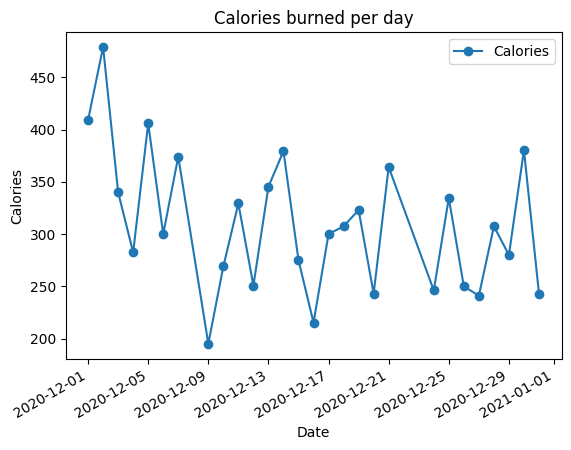

In [19]:
import matplotlib.pyplot as plt

df.plot(x="Date", y="Calories", kind="line", marker="o", title="Calories burned per day")
plt.ylabel("Calories")
plt.show()

In [20]:
df.to_csv("cleaned_data.csv", index=False)

The chart shows calories burned per workout day in December 2020. The highest was 479 calories on 2020-12-02. The cleaned dataset (28 rows, 8 columns) was saved as cleaned_data.csv.

## What I did in this project

I loaded the data and found that it has 32 rows and 5 columns. There was 1 missing date, 2 missing calories and 1 duplicate row. The dates also had quote marks in them.

To clean it, I removed the duplicate row and the row with no date. I filled the 2 missing calories with the average (307.42). I also removed the quote marks from the dates and changed them to proper dates.

Then I filtered the rows. I removed the 450 minute workout because it looks like a typo, and the row where Pulse was higher than Maxpulse. After this, 28 rows are left, and 22 of them are workouts of 60 minutes or more.

I added 3 new columns. Calories_per_min is calories divided by duration. Weekday is the day name taken from the date. Intensity is High when Maxpulse is 135 or more, otherwise Normal. 6 workouts are High and 22 are Normal.

At the end I made a chart of calories burned each day in December 2020. The most calories was 479 on 2020-12-02. I saved the cleaned data as cleaned_data.csv.

Rows went from 32 to 31 (duplicate), 30 (no date), 29 (450 minute workout) and 28 (wrong pulse), so 28 rows are left at the end.